## Idea principal
- Reducir la cantidad de diagnosticos y procedimientos hasta una cantidad que siga siendo significativa
> Inicialmente, se propone utilizar la moda de la cantidad de diagnosticos y procedimiento por paciente

In [17]:
import pandas as pd
import numpy as np

In [18]:
df_test = pd.read_csv("../data/raw/dataset_elpino.csv", sep=";")
df_test

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada,...",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] ...,L89.9 - Úlcera de decúbito y area de presión n...,L08.9 - Infección local de la piel y del tejid...,B96.2 - Escherichia coli [E. coli] como causa ...,A41.5 - Sepsis por otros organnismos Gram nega...,J86.9 - Piotórax sin fístula,...,99.84 - AISLAMIENTO,88.72 - ECOCARDIOGRAFIA,90.42 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTIVO,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,91.33 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,87.03 - TOMOGRAFIA AXIAL COMPUTERIZADA CABEZA,40,Hombre,184103 - MH SEPTICEMIA W/MCC
1,"U07.1 - COVID-19, virus identificado",J12.8 - Neumonía debida a otros virus,R06.0 - Disnea,R05 - Tos,"R50.9 - Fiebre, no especificada",Z29.0 - Aislamiento,Z01.7 - Examen de laboratorio,"J96.00 - Insuficiencia respiratoria aguda, Tip...",J94.2 - Hemotórax,J92.9 - Paquipleuritis sin asbestosis,...,91.62 - EXAMEN MICROSCOPICO PIEL.CULTIVO,90.43 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTI...,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.32 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,96.59 - IRRIGACION HERIDA OTRA,90.99 - EXAMEN MICROSCOPICO DIGESTIVO INFERIOR...,53,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
2,K56.5 - Adherencias [bridas] intestinales con ...,R57.2 - Shock séptico,R57.1 - Choque hipovolémico,J80 - Síndrome de dificultad respiratoria del ...,Y95 - Afección nosocomial,J15.0 - Neumonía debida a Klebsiella pneumoniae,U82.2 - Resistencia a Betalactamasas de amplio...,B95.6 - Staphylococcus aureus como causa de en...,B96.8 - Otros agentes bacterianos especificado...,B37.1 - Candidiasis pulmonar,...,99.84 - AISLAMIENTO,91.73 - EXAMEN MICROSCOPICO HERIDA OPERATORIA....,90.53 - EXAMEN MICROSCOPICO SANGRE.CULTIVO Y S...,99.26 - INYECCION TRANQUILIZANTE,89.39 - OTRAS MEDICIONES Y EXAMENES NO QUIRURG...,89.66 - GASOMETRIA VENA,89.65 - GASOMETRIA ARTERIA,65,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
3,K76.8 - Otras enfermedades especificadas del h...,K66.1 - Hemoperitoneo,"N18.5 - Enfermedad renal crónica, estadio 5",D64.9 - Anemia de tipo no especificado,E87.5 - Hiperpotasemia,E87.2 - Acidosis,J81 - Edema pulmonar,N17.8 - Otras insuficiencias renales agudas,J44.9 - Enfermedad pulmonar obstructiva crónic...,R41.0 - Desorientación no especificada,...,57.94 - SONDAJE URINARIO PERMANENTE,00.13 - INYECCION NESIRITIDE,00.17 - INFUSON AGENTE VASOPRESOR,99.04 - TRANSFUSION CONCENTRADO HEMATIES,99.18 - INYECCION ELECTROLITO,99.21 - INYECCION ANTIBIOTICO,99.23 - INYECCION ESTEROIDE,61,Hombre,041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SI...
4,T81.0 - Hemorragia y hematoma que complican un...,"Y83.2 - Operación quirúrgica con anastomosis, ...",S31.1 - Herida de la pared abdominal,S36.80 - Traumatismo de otros órganos intraabd...,W31.62 - Contacto traumático con otras maquina...,"J96.09 - Insuficiencia respiratoria aguda, Tip...",J15.0 - Neumonía debida a Klebsiella pneumoniae,U82.2 - Resistencia a Betalactamasas de amplio...,"U07.1 - COVID-19, virus identificado","N39.0 - Infección de vías urinarias, sitio no ...",...,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,91.32 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,93.

In [19]:
diag_cols = [col for col in df_test.columns if 'Diag' in col and '(cod+des)' in col ]
proced_cols = [col for col in df_test.columns if 'Proced' in col and '(cod+des)' in col ]
print("Columnas de diagnóstico:", diag_cols)
print("Columnas de procedimientos:", proced_cols)
df_diagnosticos = df_test[diag_cols]
df_procedimientos = df_test[proced_cols]
print('='*64)
print("DataFrame de diagnósticos:")
print('='*64)
display(df_diagnosticos.head())
print('='*64)

print("DataFrame de procedimientos:")
print('='*64)
display(df_procedimientos.head())


Columnas de diagnóstico: ['Diag 01 Principal (cod+des)', 'Diag 02 Secundario (cod+des)', 'Diag 03 Secundario (cod+des)', 'Diag 04 Secundario (cod+des)', 'Diag 05 Secundario (cod+des)', 'Diag 06 Secundario (cod+des)', 'Diag 07 Secundario (cod+des)', 'Diag 08 Secundario (cod+des)', 'Diag 09 Secundario (cod+des)', 'Diag 10 Secundario (cod+des)', 'Diag 11 Secundario (cod+des)', 'Diag 12 Secundario (cod+des)', 'Diag 13 Secundario (cod+des)', 'Diag 14 Secundario (cod+des)', 'Diag 15 Secundario (cod+des)', 'Diag 16 Secundario (cod+des)', 'Diag 17 Secundario (cod+des)', 'Diag 18 Secundario (cod+des)', 'Diag 19 Secundario (cod+des)', 'Diag 20 Secundario (cod+des)', 'Diag 21 Secundario (cod+des)', 'Diag 22 Secundario (cod+des)', 'Diag 23 Secundario (cod+des)', 'Diag 24 Secundario (cod+des)', 'Diag 25 Secundario (cod+des)', 'Diag 26 Secundario (cod+des)', 'Diag 27 Secundario (cod+des)', 'Diag 28 Secundario (cod+des)', 'Diag 29 Secundario (cod+des)', 'Diag 30 Secundario (cod+des)', 'Diag 31 Secund

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Diag 26 Secundario (cod+des),Diag 27 Secundario (cod+des),Diag 28 Secundario (cod+des),Diag 29 Secundario (cod+des),Diag 30 Secundario (cod+des),Diag 31 Secundario (cod+des),Diag 32 Secundario (cod+des),Diag 33 Secundario (cod+des),Diag 34 Secundario (cod+des),Diag 35 Secundario (cod+des)
0,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada,...",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] ...,L89.9 - Úlcera de decúbito y area de presión n...,L08.9 - Infección local de la piel y del tejid...,B96.2 - Escherichia coli [E. coli] como causa ...,A41.5 - Sepsis por otros organnismos Gram nega...,J86.9 - Piotórax sin fístula,...,Z93.3 - Colostomía,Z99.2 - Dependencia de diálisis renal,Z91.6 - Historia personal de otro trauma físico,-,-,-,-,-,-,-
1,"U07.1 - COVID-19, virus identificado",J12.8 - Neumonía debida a otros virus,R06.0 - Disnea,R05 - Tos,"R50.9 - Fiebre, no especificada",Z29.0 - Aislamiento,Z01.7 - Examen de laboratorio,"J96.00 - Insuficiencia respiratoria aguda, Tip...",J94.2 - Hemotórax,J92.9 - Paquipleuritis sin asbestosis,...,-,-,-,-,-,-,-,-,-,-
2,K56.5 - Adherencias [bridas] intestinales con ...,R57.2 - Shock séptico,R57.1 - Choque hipovolémico,J80 - Síndrome de dificultad respiratoria del ...,Y95 - Afección nosocomial,J15.0 - Neumonía debida a Klebsiella pneumoniae,U82.2 - Resistencia a Betalactamasas de amplio...,B95.6 - Staphylococcus aureus como causa de en...,B96.8 - Otros agentes bacterianos especificado...,B37.1 - Candidiasis pulmonar,...,J98.4 - Otros trastornos del pulmón,"U07.1 - COVID-19, virus identificado",Z29.0 - Aislamiento,Z01.7 - Examen de laboratorio,Z20.8 - Contacto con y exposición a otras enfe...,Z88.0 - Historia personal de alergia a penicilina,Z72.0 - Problemas relacionados con el uso del ...,-,-,-
3,K76.8 - Otras enfermedades especificadas del h...,K66.1 - Hemoperitoneo,"N18.5 - Enfermedad renal crónica, estadio 5",D64.9 - Anemia de tipo no especificado,E87.5 - Hiperpotasemia,E87.2 - Acidosis,J81 - Edema pulmonar,N17.8 - Otras insuficiencias renales agudas,J44.9 - Enfermedad pulmonar obstructiva crónic...,R41.0 - Desorientación no especificada,...,-,-,-,-,-,-,-,-,-,-
4,T81.0 - Hemorragia y hematoma que complican un...,"Y83.2 - Operación quirúrgica con anastomosis, ...",S31.1 - Herida de la pared abdominal,S36.80 - Traumatismo de otros órganos intraabd...,W31.62 - Contacto traumático con otras maquina...,"J96.09 - Insuficiencia respiratoria aguda, Tip...",J15.0 - Neumonía debida a Klebsiella pneumoniae,U82.2 - Resistencia a Betalactamasas de amplio...,"U07.1 - COVID-19, virus identificado","N39.0 - Infección de vías urinarias, sitio no ...",...,-,-,-,-,-,-,-,-,-,-


DataFrame de procedimientos:


,Proced 01 Principal (cod+des),Proced 02 Secundario (cod+des),Proced 03 Secundario (cod+des),Proced 04 Secundario (cod+des),Proced 05 Secundario (cod+des),Proced 06 Secundario (cod+des),Proced 07 Secundario (cod+des),Proced 08 Secundario (cod+des),Proced 09 Secundario (cod+des),Proced 10 Secundario (cod+des),...,Proced 21 Secundario (cod+des),Proced 22 Secundario (cod+des),Proced 23 Secundario (cod+des),Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des)
0,"86.28 - DESBRIDAMIENTO HERIDA,INFECCION O QUEM...",34.91 - TORACOCENTESIS,88.38 - TOMOGRAFIA AXIAL COMPUTERIZADA OTRA,87.41 - TOMOGRAFIA AXIAL COMPUTERIZADA TORAX,88.75 - ECOGRAFIA APARATO URINARIO,88.01 - TOMOGRAFIA AXIAL COMPUTERIZADA ABDOMEN,88.43 - ARTERIOGRAFIA ARTERIA PULMONAR,88.41 - ARTERIOGRAFIA ARTERIA CEREBRAL,87.44 - RADIOGRAFIA TORAX RUTINARIA,99.29 - INYECCION SUSTANCIA TERAPEUTICA O PROF...,...,39.95 - HEMODIALISIS,99.04 - TRANSFUSION CONCENTRADO HEMATIES,90.39 - EXAMEN MICROSCOPICO ORL.OTRO,99.84 - AISLAMIENTO,88.72 - ECOCARDIOGRAFIA,90.42 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTIVO,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,91.33 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,87.03 - TOMOGRAFIA AXIAL COMPUTERIZADA CABEZA
1,31.1 - TRAQUEOSTOMIA TEMPORAL,"86.28 - DESBRIDAMIENTO HERIDA,INFECCION O QUEM...",96.72 - VENTILACION MECANICA CONTINUA OTRA.DUR...,93.90 - RESPIRACION PRESION POSITIVA CONTINUA ...,89.7 - EXAMEN FISICO GENERAL,88.01 - TOMOGRAFIA AXIAL COMPUTERIZADA ABDOMEN,87.41 - TOMOGRAFIA AXIAL COMPUTERIZADA TORAX,34.04 - INTUBACION INTERCOSTAL PARA DRENAJE,88.43 - ARTERIOGRAFIA ARTERIA PULMONAR,93.96 - ENRIQUECIMIENTO OXIGENO OTRO,...,89.65 - GASOMETRIA ARTERIA,91.69 - EXAMEN MICROSCOPICO PIEL.OTRO,87.44 - RADIOGRAFIA TORAX RUTINARIA,91.62 - EXAMEN MICROSCOPICO PIEL.CULTIVO,90.43 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTI...,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.32 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,96.59 - IRRIGACION HERIDA OTRA,90.99 - EXAMEN MICROSCOPICO DIGESTIVO INFERIOR...
2,"86.22 - DESBRIDAMIENTO HERIDA,INFECCION O QUEM...",54.59 - LISIS ADHERENCIA PERITONEO.OTRA,96.72 - VENTILACION MECANICA CONTINUA OTRA.DUR...,31.1 - TRAQUEOSTOMIA TEMPORAL,45.13 - ESOFAGOGASTRODUODENOSCOPIA [EGD],87.41 - TOMOGRAFIA AXIAL COMPUTERIZADA TORAX,87.03 - TOMOGRAFIA AXIAL COMPUTERIZADA CABEZA,88.01 - TOMOGRAFIA AXIAL COMPUTERIZADA ABDOMEN,88.43 - ARTERIOGRAFIA ARTERIA PULMONAR,88.72 - ECOCARDIOGRAFIA,...,38.93 - CATETERISMO VENA OTRO,91.33 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,90.39 - EXAMEN MICROSCOPICO ORL.OTRO,99.84 - AISLAMIENTO,91.73 - EXAMEN MICROSCOPICO HERIDA OPERATORIA....,90.53 - EXAMEN MICROSCOPICO SANGRE.CULTIVO Y S...,99.26 - INYECCION TRANQUILIZANTE,89.39 - OTRAS MEDICIONES Y EXAMENES NO QUIRURG...,89.66 - GASOMETRIA VENA,89.65 - GASOMETRIA ARTERIA
3,54.19 - LAPAROTOMIA.OTRA,39.98 - CONTROL HEMORRAGIA NEOM,"86.28 - DESBRIDAMIENTO HERIDA,INFECCION O QUEM...",54.62 - CIERRE DIFERIDO HERIDA ABDOMEN EN GRAN...,96.72 - VENTILACION MECANICA CONTINUA OTRA.DUR...,96.04 - INTUBACION ENDOTRAQUEAL,87.41 - TOMOGRAFIA AXIAL COMPUTERIZADA TORAX,88.01 - TOMOGRAFIA AXIAL COMPUTERIZADA ABDOMEN,88.38 - TOMOGRAFIA AXIAL COMPUTERIZADA OTRA,88.41 - ARTERIOGRAFIA ARTERIA CEREBRAL,...,39.95 - HEMODIALISIS,96.59 - IRRIGACION HERIDA OTRA,94.19 - ENTREVISTA Y EVALUACION PSIQUIATRICA.OTRA,57.94 - SONDAJE URINARIO PERMANENTE,00.13 - INYECCION NESIRITIDE,00.17 - INFUSON AGENTE VASOPRESOR,99.04 - TRANSFUSION CONCENTRADO HEMATIES,99.18 - INYECCION ELECTROLITO,99.21 - INYECCION ANTIBIOTICO,99.23 - INYECCION ESTEROIDE
4,54.11 - LAPAROTOMIA EXPLORATORIA,45.90 - ANASTOMOSIS INTESTINO.NEOM,46.73 - SUTURA INTESTINO DELGADO SALVO DUODENO,46.20 - ILEOSTOMIA.NEOM,"86.28 - DESBRIDAMIENTO HERIDA,INFECCION O QUEM...

ya habiendo separado los díagnósticos de los procedimientos, procedemos a calcular la moda de cuantos diag y procedimientos se tienen por paciente

In [20]:
df_test['num_diagnosticos'] = (df_diagnosticos != "-").sum(axis=1)
df_test['num_procedimientos'] = (df_procedimientos != "-").sum(axis=1)

# print(df_test['num_diagnosticos'].value_counts().sort_index())
moda_diag = df_test['num_diagnosticos'].mode()[0]
print(f"Moda de diagnósticos: {moda_diag}")

# print(df_test['num_procedimientos'].value_counts().sort_index())
moda_proc = df_test['num_procedimientos'].mode()[0]
print(f"Moda de procedimientos: {moda_proc}")

Moda de diagnósticos: 2
Moda de procedimientos: 11


In [21]:
diag_cols_reducidos = diag_cols[:2]
proced_cols_reducidos = proced_cols[:11]

df_test_2 = df_test[diag_cols_reducidos + proced_cols_reducidos+ ['Edad en años', 'Sexo (Desc)', 'GRD']]
df_test_2


,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Proced 01 Principal (cod+des),Proced 02 Secundario (cod+des),Proced 03 Secundario (cod+des),Proced 04 Secundario (cod+des),Proced 05 Secundario (cod+des),Proced 06 Secundario (cod+des),Proced 07 Secundario (cod+des),Proced 08 Secundario (cod+des),Proced 09 Secundario (cod+des),Proced 10 Secundario (cod+des),Proced 11 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"86.28 - DESBRIDAMIENTO HERIDA,INFECCION O QUEM...",34.91 - TORACOCENTESIS,88.38 - TOMOGRAFIA AXIAL COMPUTERIZADA OTRA,87.41 - TOMOGRAFIA AXIAL COMPUTERIZADA TORAX,88.75 - ECOGRAFIA APARATO URINARIO,88.01 - TOMOGRAFIA AXIAL COMPUTERIZADA ABDOMEN,88.43 - ARTERIOGRAFIA ARTERIA PULMONAR,88.41 - ARTERIOGRAFIA ARTERIA CEREBRAL,87.44 - RADIOGRAFIA TORAX RUTINARIA,99.29 - INYECCION SUSTANCIA TERAPEUTICA O PROF...,99.19 - INYECCION ANTICOAGULANTE,40,Hombre,184103 - MH SEPTICEMIA W/MCC
1,"U07.1 - COVID-19, virus identificado",J12.8 - Neumonía debida a otros virus,31.1 - TRAQUEOSTOMIA TEMPORAL,"86.28 - DESBRIDAMIENTO HERIDA,INFECCION O QUEM...",96.72 - VENTILACION MECANICA CONTINUA OTRA.DUR...,93.90 - RESPIRACION PRESION POSITIVA CONTINUA ...,89.7 - EXAMEN FISICO GENERAL,88.01 - TOMOGRAFIA AXIAL COMPUTERIZADA ABDOMEN,87.41 - TOMOGRAFIA AXIAL COMPUTERIZADA TORAX,34.04 - INTUBACION INTERCOSTAL PARA DRENAJE,88.43 - ARTERIOGRAFIA ARTERIA PULMONAR,93.96 - ENRIQUECIMIENTO OXIGENO OTRO,93.94 - AEROSOLTERAPIA,53,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
2,K56.5 - Adherencias [bridas] intestinales con ...,R57.2 - Shock séptico,"86.22 - DESBRIDAMIENTO HERIDA,INFECCION O QUEM...",54.59 - LISIS ADHERENCIA PERITONEO.OTRA,96.72 - VENTILACION MECANICA CONTINUA OTRA.DUR...,31.1 - TRAQUEOSTOMIA TEMPORAL,45.13 - ESOFAGOGASTRODUODENOSCOPIA [EGD],87.41 - TOMOGRAFIA AXIAL COMPUTERIZADA TORAX,87.03 - TOMOGRAFIA AXIAL COMPUTERIZADA CABEZA,88.01 - TOMOGRAFIA AXIAL COMPUTERIZADA ABDOMEN,88.43 - ARTERIOGRAFIA ARTERIA PULMONAR,88.72 - ECOCARDIOGRAFIA,33.22 - BRONCOSCOPIA FLEXIBLE,65,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
3,K76.8 - Otras enfermedades especificadas del h...,K66.1 - Hemoperitoneo,54.19 - LAPAROTOMIA.OTRA,39.98 - CONTROL HEMORRAGIA NEOM,"86.28 - DESBRIDAMIENTO HERIDA,INFECCION O QUEM...",54.62 - CIERRE DIFERIDO HERIDA ABDOMEN EN GRAN...,96.72 - VENTILACION MECANICA CONTINUA OTRA.DUR...,96.04 - INTUBACION ENDOTRAQUEAL,87.41 - TOMOGRAFIA AXIAL COMPUTERIZADA TORAX,88.01 - TOMOGRAFIA AXIAL COMPUTERIZADA ABDOMEN,88.38 - TOMOGRAFIA AXIAL COMPUTERIZADA OTRA,88.41 - ARTERIOGRAFIA ARTERIA CEREBRAL,88.47 - ARTERIOGRAFIA ARTERIA INTRABDOMINAL OTRA,61,Hombre,041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SI...
4,T81.0 - Hemorragia y hematoma que complican un...,"Y83.2 - Operación quirúrgica con anastomosis, ...",54.11 - LAPAROTOMIA EXPLORATORIA,45.90 - ANASTOMOSIS INTESTINO.NEOM,46.73 - SUTURA INTESTINO DELGADO SALVO DUODENO,46.20 - ILEOSTOMIA.NEOM,"86.28 - DESBRIDAMIENTO HERIDA,INFECCION O QUEM...",54.19 - LAPAROTOMIA.OTRA,89.7 - EXAMEN FISICO GENERAL,96.04 - INTUBACION ENDOTRAQUEAL,96.72 - VENTILACION MECANICA CONTINUA OTRA.DUR...,54.4 - ESCISION PERITONEO LOCAL,88.47 - ARTERIOGRAFIA ARTERIA INTRABDOMINAL OTRA,30,Hombre,041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SI...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14556,E10.1 - Diabetes mellitus tipo 1 con cetoacidosis,"J45.9 - Asma, no especificada",87.44 - RADIOGRAFIA TORAX RUTINARIA,89.7 - EXAMEN FISICO GENERAL,90.59 - EXAMEN MICROSCOPICO SANGRE.OTRO,89.66 - GASOMETRIA VENA,99.18 - INYECCION ELECTROLITO,99.17 - INYECCION INSULINA,90.39 - EXAMEN MICROSCOPICO ORL.OTRO,99.84 - AISLAMIENTO,57.94 - SONDAJE URINARIO PERMANENTE,38.93 - CATETERISMO VENA OTRO,-,26,Mujer,104101 - MH DIABETES Y ENFERMEDADES METABÓLICA...
14557,"S09.9 - Traumatismo de la cabeza, no especificado","W18.24 - Otras caídas en el mismo nivel, escue...",87.03 - TOMOGRAFIA AXIAL COMPUTE

In [22]:
import sys
sys.path.append("..")
from src.data.preprocces import preprocess
cie_10 = pd.read_excel('../data/raw/CIE-10.xlsx')
cie_9  = pd.read_excel('../data/raw/CIE-9.xlsx')

pre = preprocess()
pre.CIE10_to_categorie(df_test_2)
pre.CIE9_to_categorie(df_test_2)
cie_10['Capítulo'].unique()
cie_9['Capítulo'].unique()
cie_9['Código']
df_test_2['Proced 01 Principal (cod+des)'].head()
cie_10[['Código', 'Capítulo']]
map_cie10 = (
    cie_10[['Código', 'Capítulo']]
    .dropna()
    .assign(
        Categoria=lambda x: x['Código'].astype(str).str.strip().str.upper().str[:3],
        Capitulo=lambda x: x['Capítulo'].astype(str).str.strip()
    )[['Categoria', 'Capitulo']]
    .drop_duplicates('Categoria')
)
cie_10_dict = dict(zip(map_cie10['Categoria'], map_cie10['Capitulo']))
print(cie_10_dict['X80'])
def CIE9_to_categorie(df):
        cols_proc = [c for c in df.columns if  'Proced' in c and '(cod+des)'in c]
        for col in cols_proc:
            df[col] = (
                df[col].fillna('').astype(str)
                .str.split(" - ").str[0].str[:2])


map_cie9 = (
    cie_9[['Código', 'Capítulo']]
    .dropna()
    .assign(
        Categoria=lambda x: (
            x['Código']
            .astype(str)
            .str.strip()
            .str.split('.').str[0]  
            .str[:2]
        ),
        Capitulo=lambda x: x['Capítulo'].astype(str).str.strip()
    )[['Categoria', 'Capitulo']]
    .drop_duplicates('Categoria')
)
cie_9_dict = dict(zip(map_cie9['Categoria'], map_cie9['Capitulo']))
cie_10_dict.update({
    '-': 'SIN_CODIGO'
})
cie_9_dict.update({
    '-': 'SIN_CODIGO'
})

def CIE10_to_chapter(df):
        cols_diag = [c for c in df.columns if  'Diag' in c and '(cod+des)'in c]
        for col in cols_diag:
            df[col] = (
                df[col].map(cie_10_dict)
            )
def CIE9_to_chapter( df):
    cols_proc = [c for c in df.columns if  'Proced' in c and '(cod+des)'in c]
    for col in cols_proc:
        df[col] = (
            df[col].astype(str).map(cie_9_dict)
        )
CIE9_to_chapter(df_test_2)
CIE10_to_chapter(df_test_2)
df_test_2

Cap.20  CAUSAS EXTERNAS DE MORBILIDAD (V00-Y99)


,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Proced 01 Principal (cod+des),Proced 02 Secundario (cod+des),Proced 03 Secundario (cod+des),Proced 04 Secundario (cod+des),Proced 05 Secundario (cod+des),Proced 06 Secundario (cod+des),Proced 07 Secundario (cod+des),Proced 08 Secundario (cod+des),Proced 09 Secundario (cod+des),Proced 10 Secundario (cod+des),Proced 11 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...,15. (85 86) OPERACIONES SOBRE EL APARATO TEGUM...,06. (30 34) OPERACIONES SOBRE EL APARATO RESPI...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,40,Hombre,184103 - MH SEPTICEMIA W/MCC
1,Cap.22 CÓDIGOS PARA SITUACIONES ESPECIALES (U...,Cap.10 ENFERMEDADES DEL APARATO RESPIRATORIO ...,06. (30 34) OPERACIONES SOBRE EL APARATO RESPI...,15. (85 86) OPERACIONES SOBRE EL APARATO TEGUM...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,06. (30 34) OPERACIONES SOBRE EL APARATO RESPI...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,53,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
2,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,"Cap.18 SÍNTOMAS, SIGNOS Y RESULTADOS ANORMALE...",15. (85 86) OPERACIONES SOBRE EL APARATO TEGUM...,09. (42 54) OPERACIONES SOBRE EL APARATO DIGES...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,06. (30 34) OPERACIONES SOBRE EL APARATO RESPI...,09. (42 54) OPERACIONES SOBRE EL APARATO DIGES...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,06. (30 34) OPERACIONES SOBRE EL APARATO RESPI...,65,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
3,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,09. (42 54) OPERACIONES SOBRE EL APARATO DIGES...,07. (35 39) OPERACIONES SOBRE EL APARATO CARDI...,15. (85 86) OPERACIONES SOBRE EL APARATO TEGUM...,09. (42 54) OPERACIONES SOBRE EL APARATO DIGES...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,61,Hombre,041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SI...
4,"Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS ...",Cap.20 CAUSAS EXTERNAS DE MORBILIDAD (V00-Y99),09. (42 54) OPERACIONES SOBRE EL APARATO DIGES...,09. (42 54) OPERACIONES SOBRE EL APARATO DIGES...,09. (42 54) OPERACIONES SOBRE EL APARATO DIGES...,09. (42 54) OPERACIONES SOBRE EL APARATO DIGES...,15. (85 86) OPERACIONES SOBRE EL APARATO TEGUM...,09. (42 54) OPERACIONES SOBRE EL APARATO DIGES...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,09. (42 54) OPERACIONES SOBRE EL APARATO DIGES...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,30,Hombre,041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SI...
...,...,...,...,...,...,...,...,...,...,..

In [23]:
df_test_2['Sexo (Desc)'] = (
    df_test_2['Sexo (Desc)']
    .astype(str).str.strip().str.lower()
    .map({'hombre': 0, 'mujer': 1})
)
df_test_2

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Proced 01 Principal (cod+des),Proced 02 Secundario (cod+des),Proced 03 Secundario (cod+des),Proced 04 Secundario (cod+des),Proced 05 Secundario (cod+des),Proced 06 Secundario (cod+des),Proced 07 Secundario (cod+des),Proced 08 Secundario (cod+des),Proced 09 Secundario (cod+des),Proced 10 Secundario (cod+des),Proced 11 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...,15. (85 86) OPERACIONES SOBRE EL APARATO TEGUM...,06. (30 34) OPERACIONES SOBRE EL APARATO RESPI...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,40,0,184103 - MH SEPTICEMIA W/MCC
1,Cap.22 CÓDIGOS PARA SITUACIONES ESPECIALES (U...,Cap.10 ENFERMEDADES DEL APARATO RESPIRATORIO ...,06. (30 34) OPERACIONES SOBRE EL APARATO RESPI...,15. (85 86) OPERACIONES SOBRE EL APARATO TEGUM...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,06. (30 34) OPERACIONES SOBRE EL APARATO RESPI...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,53,0,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
2,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,"Cap.18 SÍNTOMAS, SIGNOS Y RESULTADOS ANORMALE...",15. (85 86) OPERACIONES SOBRE EL APARATO TEGUM...,09. (42 54) OPERACIONES SOBRE EL APARATO DIGES...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,06. (30 34) OPERACIONES SOBRE EL APARATO RESPI...,09. (42 54) OPERACIONES SOBRE EL APARATO DIGES...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,06. (30 34) OPERACIONES SOBRE EL APARATO RESPI...,65,0,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
3,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,09. (42 54) OPERACIONES SOBRE EL APARATO DIGES...,07. (35 39) OPERACIONES SOBRE EL APARATO CARDI...,15. (85 86) OPERACIONES SOBRE EL APARATO TEGUM...,09. (42 54) OPERACIONES SOBRE EL APARATO DIGES...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,61,0,041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SI...
4,"Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS ...",Cap.20 CAUSAS EXTERNAS DE MORBILIDAD (V00-Y99),09. (42 54) OPERACIONES SOBRE EL APARATO DIGES...,09. (42 54) OPERACIONES SOBRE EL APARATO DIGES...,09. (42 54) OPERACIONES SOBRE EL APARATO DIGES...,09. (42 54) OPERACIONES SOBRE EL APARATO DIGES...,15. (85 86) OPERACIONES SOBRE EL APARATO TEGUM...,09. (42 54) OPERACIONES SOBRE EL APARATO DIGES...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,09. (42 54) OPERACIONES SOBRE EL APARATO DIGES...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,30,0,041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SI...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

Tipos de datos: 


,tipo
Diag 01 Principal (cod+des),str
Diag 02 Secundario (cod+des),str
Proced 01 Principal (cod+des),str
Proced 02 Secundario (cod+des),str
Proced 03 Secundario (cod+des),str
Proced 04 Secundario (cod+des),str
Proced 05 Secundario (cod+des),str
Proced 06 Secundario (cod+des),str
Proced 07 Secundario (cod+des),str
Proced 08 Secundario (cod+des),str



 Valores faltantes por columna


,Valores faltantes
Diag 01 Principal (cod+des),0
Diag 02 Secundario (cod+des),32
Proced 01 Principal (cod+des),30
Proced 02 Secundario (cod+des),469
Proced 03 Secundario (cod+des),1215
Proced 04 Secundario (cod+des),924
Proced 05 Secundario (cod+des),195
Proced 06 Secundario (cod+des),67
Proced 07 Secundario (cod+des),67
Proced 08 Secundario (cod+des),62



Variables con alta cardinalidad ( > 100 categorías):


,Unique_Values
GRD,526



 Estadística descriptiva


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Diag 01 Principal (cod+des),14561,21,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",3896,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diag 02 Secundario (cod+des),14529,23,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",3184,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Proced 01 Principal (cod+des),14531,15,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,7321,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Proced 02 Secundario (cod+des),14092,15,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,10176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Proced 03 Secundario (cod+des),13346,15,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,11353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Proced 04 Secundario (cod+des),13637,12,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,11899,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Proced 05 Secundario (cod+des),14366,14,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,12271,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Proced 06 Secundario (cod+des),14494,11,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,11903,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Proced 07 Secundario (cod+des),14494,11,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,11581,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Proced 08 Secundario (cod+des),14499,11,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,10753,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Distribución de la variable objetivo:


,conteo
GRD,
146101 - PH CESÁREA,813
"146121 - PH PARTO VAGINAL CON PROCED., EXCEPTO ESTERILIZACIÓN Y/O DILATACIÓN Y LEGRADO",639
146131 - PH PARTO VAGINAL,538
"158171 - MH NEONATO, PESO AL NACER >2499 GR SIN PROCEDIMIENTO MAYOR",389
134161 - MH TRASTORNOS DEL ANTEPARTO,325
...,...
164142 - MH OTROS TRASTORNOS DE LA SANGRE Y ÓRGANOS HEMATOPOYÉTICOS W/CC,1
"101202 - PH PROCEDIMIENTOS SOBRE TIROIDES, PARATIROIDES Y CONDUCTO TIROGLOSO W/CC",1
134101 - MH NEOPLASIA DEL APARATO REPRODUCTOR FEMENINO,1


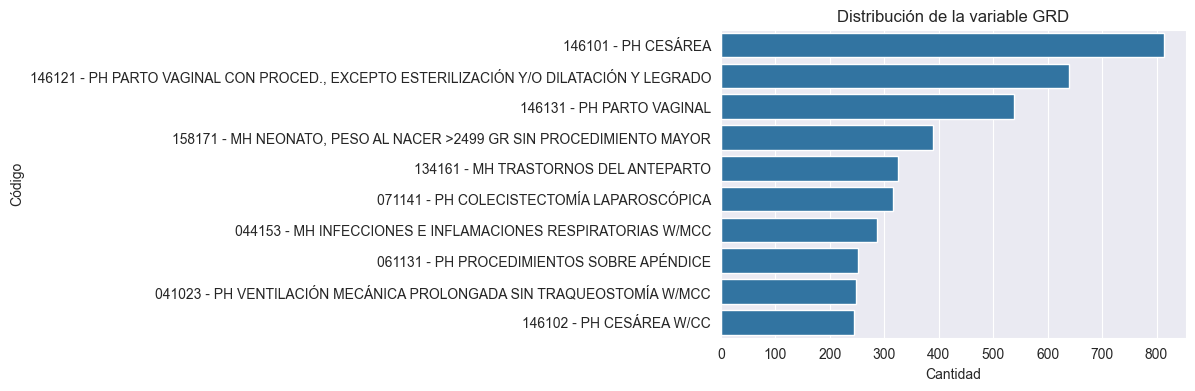


Columnas categóricas - Top 5 valores:

Diag 01 Principal (cod+des):
Diag 01 Principal (cod+des)
Cap.15  EMBARAZO, PARTO Y PUERPERIO (O00-O9A)                3896
Cap.11  ENFERMEDADES DEL APARATO DIGESTIVO (K00-K95)         2029
Cap.09  ENFERMEDADES DEL APARATO CIRCULATORIO (I00-I99)      1247
Cap.14  ENFERMEDADES DEL APARATO GENITOURINARIO (N00-N99)    1215
Cap.10  ENFERMEDADES DEL APARATO RESPIRATORIO (J00-J99)      1192
Name: count, dtype: int64

Diag 02 Secundario (cod+des):
Diag 02 Secundario (cod+des)
Cap.15  EMBARAZO, PARTO Y PUERPERIO (O00-O9A)                             3184
Cap.09  ENFERMEDADES DEL APARATO CIRCULATORIO (I00-I99)                   1692
Cap.10  ENFERMEDADES DEL APARATO RESPIRATORIO (J00-J99)                   1526
SIN_CODIGO                                                                1209
Cap.04  ENFERMEDADES ENDOCRINAS, NUTRICIONALES Y METABÓLICAS (E00-E89)     828
Name: count, dtype: int64

Proced 01 Principal (cod+des):
Proced 01 Principal (cod+des)
16. 

In [25]:
from src.data.EDA import EDA
EDA = EDA()
EDA.summaryEda(df_test_2, 'GRD')

Aviso: stratify no fue posible (clases con muy pocos casos). Se usa split sin stratify.
=== Holdout Test ===
Accuracy:          0.3038
Balanced Accuracy: 0.1426
F1 Macro:          0.1179

Reporte por clase:
                                                                                                           precision    recall  f1-score   support

                           014112 - MH ENFERMEDADES DEGENERATIVAS Y NEOPLÁSICAS DEL SISTEMA NERVIOSO W/CC       0.00      0.00      0.00         2
                                                        014131 - MH HEMORRAGIA INTRACRANEAL NO TRAUMÁTICA       0.00      0.00      0.00         2
                                                   014132 - MH HEMORRAGIA INTRACRANEAL NO TRAUMÁTICA W/CC       0.00      0.00      0.00         3
                                                  014133 - MH HEMORRAGIA INTRACRANEAL NO TRAUMÁTICA W/MCC       0.00      0.00      0.00         3
                                                        0

PicklingError: Could not pickle the task to send it to the workers.